## Annotate the peaks with associated genes

- last updated: 5/11/2025

- Use Signac's LinkPeaks function to map the peaks with "associated" genes, whose RNA expression is highly correlated with the chromatin accessibility.


In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import sys
import os

# rapids-singlecell
import cupy as cp
import rapids_singlecell as rsc

In [2]:
# figure parameter setting
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
mpl.rcParams.update(mpl.rcParamsDefault) #Reset rcParams to default

# Editable text and proper LaTeX fonts in illustrator
# matplotlib.rcParams['ps.useafm'] = True
# Editable fonts. 42 is the magic number
mpl.rcParams['pdf.fonttype'] = 42
sns.set(style='whitegrid', context='paper')
# Set default DPI for saved figures
mpl.rcParams['savefig.dpi'] = 600

In [3]:
import logging
# Suppress INFO-level logs for the entire logger
logging.getLogger().setLevel(logging.WARNING)

In [4]:
# define the figure path
figpath = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/figures/peak_umap_annotated/"
os.makedirs(figpath, exist_ok=True)
sc.settings.figdir = figpath

In [5]:
# import the peaks-by-celltype&timepoint pseudobulk object
adata_peaks = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_leiden_0.4_merged_annotated.h5ad")
adata_peaks

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

### import the peak-gene linkage (Signac) data

In [17]:
# import the linked genes from Signac's LinkPeaks
linked_peaks = pd.read_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/01_Signac_processed/peak_gene_links_all_peaks.csv", index_col="peak")
linked_peaks.head()

,seqnames,start,end,width,strand,score,gene,zscore,pvalue
peak,,,,,,,,,
1-14059-14260,1,12027,14160,2134,*,-0.052304,rpl24,-6.807942,4.950224e-12
1-14625-15105,1,12027,14865,2839,*,-0.124582,rpl24,-8.962374,1.588813e-19
1-21590-23611,1,12027,22601,10575,*,-0.058221,rpl24,-2.666814,3.828702e-03
1-36495-38783,1,12027,37639,25613,*,-0.051786,rpl24,-2.690208,3.570375e-03
1-48799-50798,1,12027,49799,37773,*,-0.056344,rpl24,-3.807794,7.010610e-05


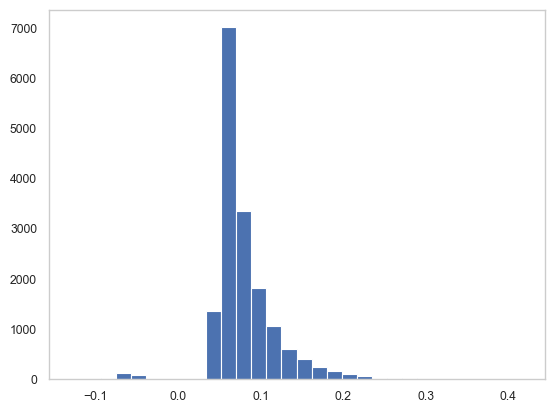

In [19]:
plt.hist(linked_peaks["score"].values, bins=30)
plt.grid(False)
plt.show()

In [30]:
# First create a new column in adata.obs to store gene linkages
adata_peaks.obs['linked_gene'] = ""
adata_peaks.obs['link_score'] = np.nan
adata_peaks.obs['link_zscore'] = np.nan
adata_peaks.obs['link_pvalue'] = np.nan

# Map values from linked_peaks to adata.obs
for idx, row in linked_peaks.iterrows():
   adata_peaks.obs.loc[idx, 'linked_gene'] = row['gene']
   adata_peaks.obs.loc[idx, 'link_score'] = row['score'] 
   adata_peaks.obs.loc[idx, 'link_zscore'] = row['zscore']
   adata_peaks.obs.loc[idx, 'link_pvalue'] = row['pvalue']
    
# Create a categorical column for whether peak is linked
adata_peaks.obs['is_linked'] = adata_peaks.obs['linked_gene'].apply(lambda x: 'Linked' if x != '' else 'Not linked')

# Print summary statistics
print(f"Total linked peaks: {(adata_peaks.obs['is_linked'] == 'Linked').sum()}")
print(f"Total unlinked peaks: {(adata_peaks.obs['is_linked'] == 'Not linked').sum()}")

Total linked peaks: 15203
Total unlinked peaks: 625631


In [39]:
adata_peaks

AnnData object with n_obs × n_vars = 640834 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

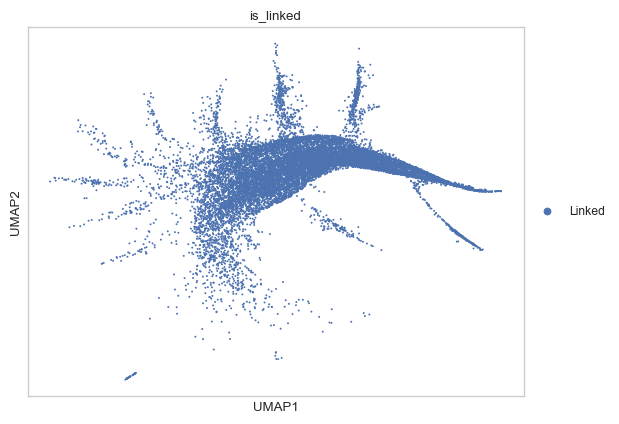

In [22]:
sc.pl.umap(adata_peaks[adata_peaks.obs["is_linked"]=="Linked"], color='is_linked')

In [23]:
# save the updated adata object
adata_peaks.write_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_leiden_0.4_merged_annotated.h5ad")

In [33]:
adata_peaks_filt = sc.read_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_leiden_0.4_merged_annotated_filtered.h5ad")
adata_peaks_filt

AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spinal_cord',

In [34]:
# filter out the 4 peaks (MT and also peaks that extended beyond the chromosome end)
adata_peaks_filtered = adata_peaks[adata_peaks.obs_names.isin(adata_peaks_filt.obs_names)]
adata_peaks_filtered

View of AnnData object with n_obs × n_vars = 640830 × 190
    obs: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'accessibility_neural_optic', 'accessibility_endoderm', 'accessibility_enteric_neurons', 'accessibility_notochord', 'accessibility_pharyngeal_arches', 'accessibility_floor_plate', 'accessibility_epidermis', 'accessibility_pronephros', 'accessibility_neural_floor_plate', 'accessibility_lateral_plate_mesoderm', 'accessibility_midbrain_hindbrain_boundary', 'accessibility_neural', 'accessibility_neurons', 'accessibility_neural_posterior', 'accessibility_neural_crest', 'accessibility_PSM', 'accessibility_fast_muscle', 'accessibility_endocrine_pancreas', 'accessibility_heart_myocardium', 'accessibility_neural_telencephalon', 'accessibility_optic_cup', 'accessibility_primordial_germ_cells', 'accessibility_differentiating_neurons', 'accessibility_muscle', 'accessibility_tail_bud', 'accessibility_hindbrain', 'accessibility_somites', 'accessibility_spina

In [40]:
# copy over the metadata
obs_fields = ['chrom', 'start', 'end', 'peak_type', 'length', 'gene_body_overlaps', 'nearest_gene', 'distance_to_tss', 'leiden_coarse']
for field in obs_fields:
    adata_peaks_filtered.obs[field] = adata_peaks_filtered.obs_names.map(adata_peaks_filt.obs[field])
    print(f"{field} is copied")
    

chrom is copied
start is copied
end is copied
peak_type is copied
length is copied
gene_body_overlaps is copied
nearest_gene is copied
distance_to_tss is copied
leiden_coarse is copied


In [43]:
# export the adata.obs
adata_peaks_filtered.obs.to_csv("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/all_peaks_annotated.csv")
# save the adata object
adata_peaks_filtered.write_h5ad("/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/annotated_data/objects_v2/peaks_by_pb_leiden_0.4_merged_annotated.h5ad")

## Pathway enrichment analysis

In [8]:
adata_peaks.obs.head()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,is_linked,chrom,start,end,peak_type,length,gene_body_overlaps,nearest_gene,distance_to_tss,leiden_coarse
1-32-526,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,Not linked,1,32,526,intergenic,494,,cep97,11542.0,7
1-2372-3057,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,Not linked,1,2372,3057,intergenic,685,,cep97,9107.0,12
1-3427-4032,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,Not linked,1,3427,4032,intergenic,605,,cep97,8092.0,33
1-4469-7268,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,Not linked,1,4469,7268,exonic,2799,rpl24,cep97,5953.0,26
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,Not linked,1,9541,9969,promoter,428,rpl24,cep97,2066.0,33


In [9]:
adata_peaks.obs["celltype"]

1-32-526                         neural_posterior
1-2372-3057                          neural_optic
1-3427-4032                 primordial_germ_cells
1-4469-7268                             optic_cup
1-9541-9969                                   PSM
                                  ...            
25-37496420-37496948               hatching_gland
25-37497049-37497789                       muscle
25-37498106-37500090                       neural
25-37500598-37500859        primordial_germ_cells
25-37501104-37501839    hematopoietic_vasculature
Name: celltype, Length: 640830, dtype: category
Categories (31, object): ['NMPs', 'PSM', 'differentiating_neurons', 'endocrine_pancreas', ..., 'primordial_germ_cells', 'pronephros', 'spinal_cord', 'tail_bud']

In [10]:
# Loop over unique cluster labels
for clust in range(len(adata_peaks.obs["leiden_coarse"].unique())):
    # clust= str(clust)
    print(f"Processing cluster {clust}...")
    peaks_sub = adata_peaks[adata_peaks.obs["leiden_coarse"]==clust]
    print(peaks_sub.obs["celltype"].value_counts().head(2))

Processing cluster 0...
enteric_neurons            235
differentiating_neurons    189
Name: celltype, dtype: int64
Processing cluster 1...
PSM       10178
neural     7071
Name: celltype, dtype: int64
Processing cluster 2...
enteric_neurons          6666
primordial_germ_cells    2724
Name: celltype, dtype: int64
Processing cluster 3...
neural_telencephalon    2202
optic_cup               1944
Name: celltype, dtype: int64
Processing cluster 4...
primordial_germ_cells    6185
neural                    139
Name: celltype, dtype: int64
Processing cluster 5...
epidermis         4212
hatching_gland     733
Name: celltype, dtype: int64
Processing cluster 6...
muscle            1456
hatching_gland     454
Name: celltype, dtype: int64
Processing cluster 7...
neural         13819
fast_muscle    10502
Name: celltype, dtype: int64
Processing cluster 8...
lateral_plate_mesoderm    1323
pharyngeal_arches          854
Name: celltype, dtype: int64
Processing cluster 9...
primordial_germ_cells    2261
e

In [47]:
# Load the FishEnrichR utility module
sys.path.append('/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/zebrahub-multiome-analysis/scripts/utils/')
from FishEnrichR import *

In [48]:
# Create the output directory for your GSEA results
output_dir = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/13_peak_umap_analysis/FishEnrichR_associated_genes_peak_clustering_leiden_coarse/"
os.makedirs(output_dir, exist_ok=True)

# Initialize the FishEnrichR client
enrichr = FishEnrichR()

In [68]:
clust = 0
peaks_sub = adata_peaks_filtered[adata_peaks_filtered.obs["leiden_coarse"] == clust]
peaks_sub

# Extract the list of genes from obs["associated_gene"] in this cluster
list_genes_sub = peaks_sub.obs["linked_gene"].unique().tolist()
list_genes_sub

# Remove any NaN or non-string entries
list_genes_sub = [g for g in list_genes_sub if isinstance(g, str)]
list_genes_sub

# # If no genes, skip
# if not list_genes_sub:
#     print(f"No genes found for cluster {clust}; skipping.")

# Analyze the gene list with FishEnrichR (you can change the "description" string)
result = enrichr.analyze_genes(list_genes_sub, description=f"Cluster_{clust}_genes")

# Retrieve the userListId
user_list_id = result["userListId"]

# Build an output file path (e.g. cluster_2_enrichment_WikiPathways_2018.tsv)
output_filename = f"cluster_{clust}_enrichment_WikiPathways_2018.tsv"
output_path = os.path.join(output_dir, output_filename)

In [49]:
# Loop over unique cluster labels
for clust in adata_peaks_filtered.obs["leiden_coarse"].unique():
    print(f"Processing cluster {clust}...")
    
    # Subset the AnnData to the cluster of interest
    peaks_sub = adata_peaks_filtered[adata_peaks_filtered.obs["leiden_coarse"] == clust]
    
    # Extract the list of genes from obs["associated_gene"] in this cluster
    list_genes_sub = peaks_sub.obs["linked_gene"].unique().tolist()
    # Remove any NaN or non-string entries
    list_genes_sub = [g for g in list_genes_sub if isinstance(g, str)]
    
    # If no genes, skip
    if not list_genes_sub:
        print(f"No genes found for cluster {clust}; skipping.")
        continue
    
    # Analyze the gene list with FishEnrichR (you can change the "description" string)
    result = enrichr.analyze_genes(list_genes_sub, description=f"Cluster_{clust}_genes")
    
    # Retrieve the userListId
    user_list_id = result["userListId"]
    
    # Build an output file path (e.g. cluster_2_enrichment_WikiPathways_2018.tsv)
    output_filename = f"cluster_{clust}_enrichment_WikiPathways_2018.tsv"
    output_path = os.path.join(output_dir, output_filename)
    
    # Download the WikiPathways_2018 results
    enrichr.download_results(user_list_id, output_path, 'WikiPathways_2018')
    
    print(f"  Saved WikiPathways_2018 enrichment for cluster {clust} to:\n  {output_path}")

Processing cluster 7...
  Saved WikiPathways_2018 enrichment for cluster 7 to:
  /hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/13_peak_umap_analysis/FishEnrichR_associated_genes_peak_clustering_leiden_coarse/cluster_7_enrichment_WikiPathways_2018.tsv
Processing cluster 12...
  Saved WikiPathways_2018 enrichment for cluster 12 to:
  /hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/13_peak_umap_analysis/FishEnrichR_associated_genes_peak_clustering_leiden_coarse/cluster_12_enrichment_WikiPathways_2018.tsv
Processing cluster 33...
  Saved WikiPathways_2018 enrichment for cluster 33 to:
  /hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/13_peak_umap_analysis/FishEnrichR_associated_genes_peak_clustering_leiden_coarse/cluster_33_enrichment_WikiPathways_2018.tsv
Processing cluster 26...
  Saved WikiPathways_2018 enrichment for cluster 26 to:
  /hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data

### plotting the enrichment result using a bar plot

In [50]:
def plot_pathway_enrichment(file_path, output_path, top_n=10):
    # Read the tab-separated file
    df = pd.read_csv(file_path, sep='\t')
    
    # Sort by Combined Score and get top N pathways
    df = df.sort_values('Combined Score', ascending=True).tail(top_n)
    
    # Create color list based on p-value
    colors = ['grey' if p > 0.05 else 'purple' for p in df['P-value']]
    
    # Create the plot
    plt.figure(figsize=(12, 8))
    bars = plt.barh(df['Term'], df['Combined Score'], color=colors, alpha=0.6)
    
    # Customize the plot
    plt.title('WikiPathways 2018 Enrichment', fontsize=14, pad=20)
    plt.xlabel('Combined Score', fontsize=12)
    
    # Remove pathway prefix for cleaner labels
    plt.yticks(range(len(df['Term'])), 
              [term.split('_WP')[0] for term in df['Term']], 
              fontsize=10)
    
    # Add significance legend
    plt.legend([plt.Rectangle((0,0),1,1, fc='purple', alpha=0.6),
               plt.Rectangle((0,0),1,1, fc='grey', alpha=0.6)],
              ['p < 0.05', 'p > 0.05'])
    
    # Adjust layout and save
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()

In [51]:
output_dir

'/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/13_peak_umap_analysis/FishEnrichR_associated_genes_peak_clustering_leiden_coarse/'

In [54]:
# adata_peaks_filtered.uns["leiden_coarse_colors"]

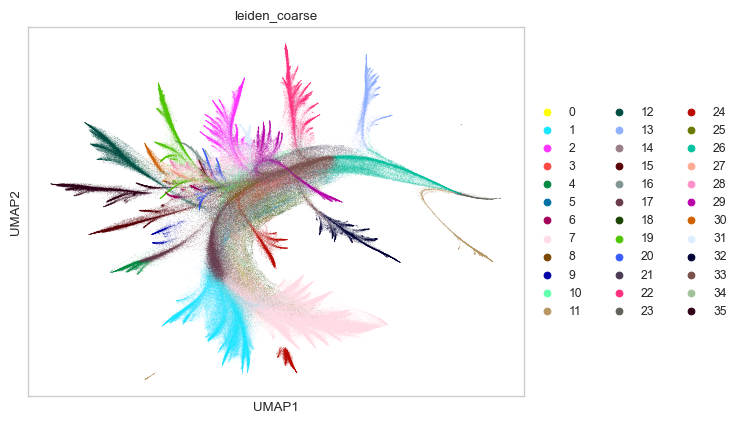

In [55]:
sc.pl.umap(adata_peaks_filtered, color="leiden_coarse")

In [57]:
import matplotlib.patches as mpatches

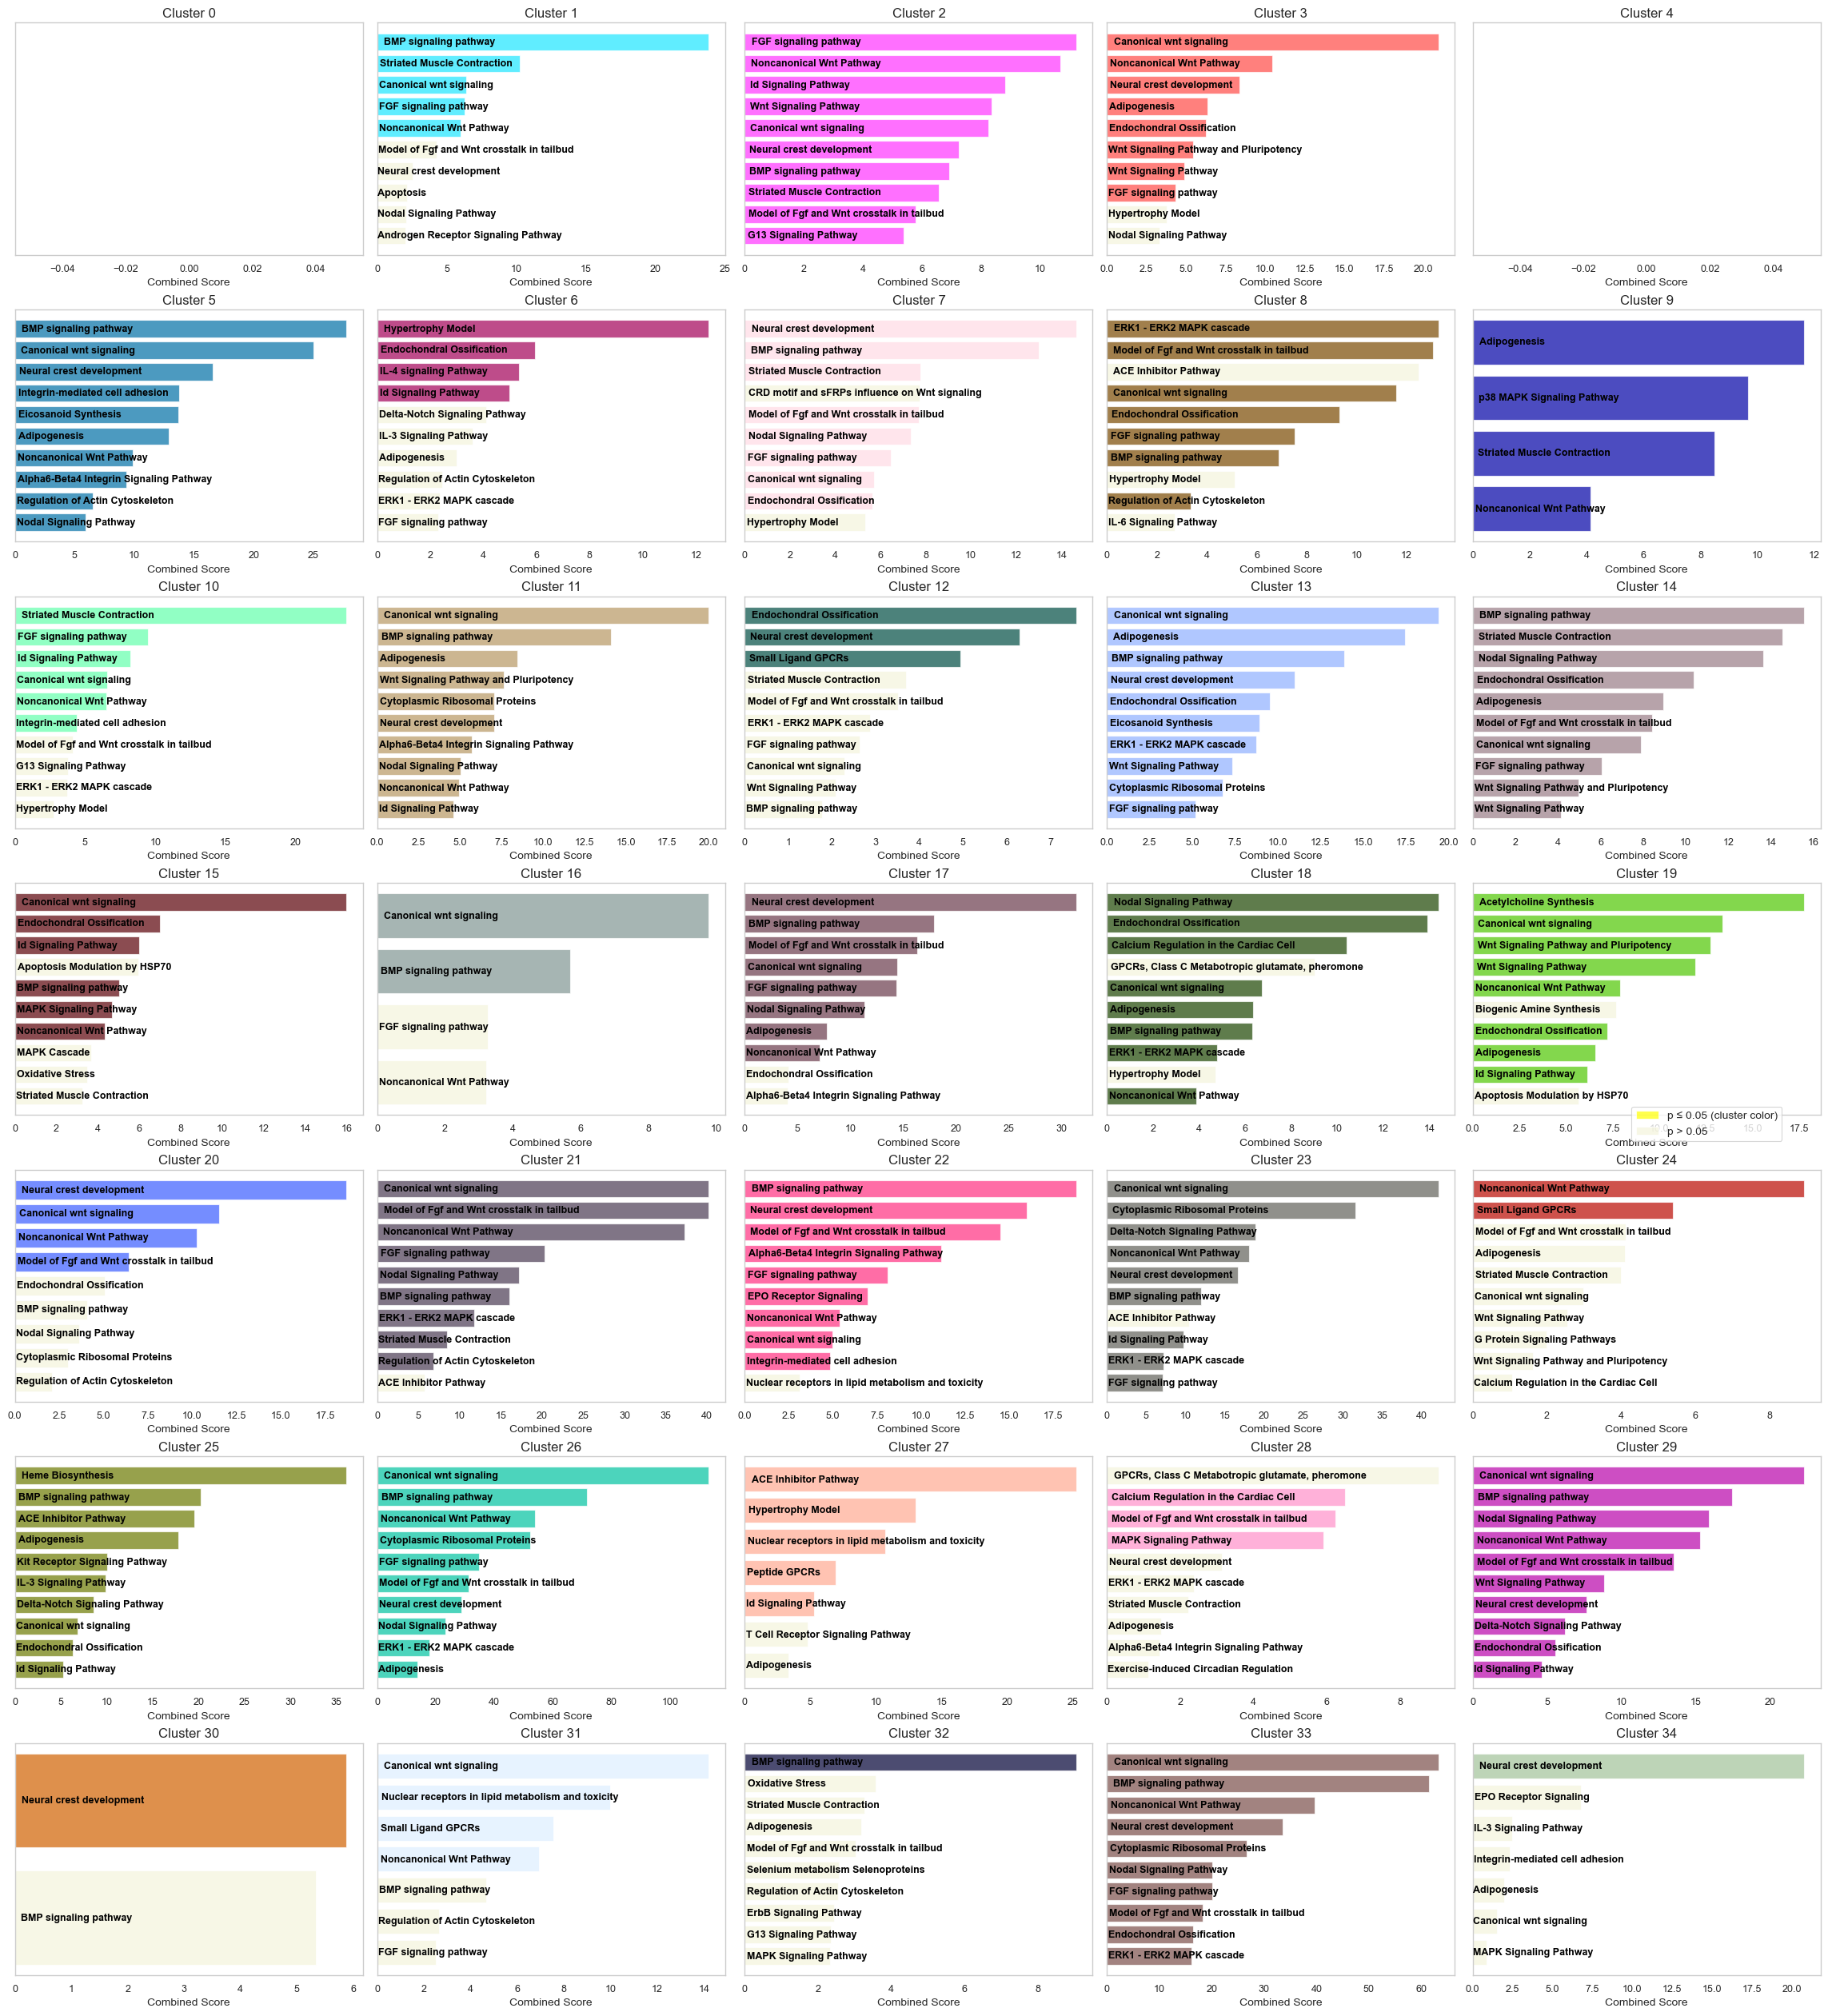

In [73]:
# Get cluster colors from the AnnData object
cluster_colors_list = adata_peaks_filtered.uns["leiden_coarse_colors"]
cluster_labels = adata_peaks_filtered.obs["leiden_coarse"].cat.categories  # Ensure order matches
cluster_colors = {int(cluster): color for cluster, color in zip(cluster_labels, cluster_colors_list)}

# Plot parameters
TITLE_SIZE = 12
LABEL_SIZE = 10
TICK_SIZE = 9
LEGEND_SIZE = 10

nrows = 8  # 8 rows
ncols = 5  # 5 columns
top_n = 10  # Number of top enriched pathways to show

# Define base directory and output path
base_dir = "/hpc/projects/data.science/yangjoon.kim/zebrahub_multiome/data/processed_data/13_peak_umap_analysis/FishEnrichR_associated_genes_peak_clustering_leiden_coarse/"
output_fig = os.path.join(base_dir, "all_clusters_pathways_labels_inside.pdf")

# Define a "non-significant" color
nonsig_color = '#F5F5DC'

# Set up the figure
width_scale = 0.70          # keep 70 % of the original width  (= 30 % shorter)
fig_width  = 6.5 * ncols * width_scale   # old width was 6.5 × ncols
fig_height = 3.5 * nrows                 # keep the original height
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(fig_width, fig_height), constrained_layout=True)

# Flatten axes array for easy indexing
axes = axes.flatten()

# Loop through clusters 0-35 explicitly
for i, cluster in enumerate(range(35)):  
    input_file = os.path.join(base_dir, f"cluster_{cluster}_enrichment_WikiPathways_2018.tsv.txt")
    
    if not os.path.exists(input_file):
        print(f"File not found for cluster {cluster}: {input_file}, skipping...")
        continue

    df = pd.read_csv(input_file, sep='\t')
    df = df.sort_values('Combined Score', ascending=True).tail(top_n)

    # Determine colors based on p-value
    colors = [
        cluster_colors.get(cluster, '#999999') if p <= 0.05 else nonsig_color
        for p in df['P-value']
    ]

    # Select the correct subplot
    ax = axes[i]

    # Remove grid lines inside the bar plots
    ax.grid(False)

    # Create horizontal bars
    bars = ax.barh(range(len(df)), df['Combined Score'], color=colors, alpha=0.7)

    # Title
    ax.set_title(f'Cluster {cluster}', fontsize=TITLE_SIZE, pad=5)

    # Remove y-ticks and y-axis labels completely
    ax.set_yticks([])
    ax.set_yticklabels([])

    # Add labels **inside** the bars
    for bar, label in zip(bars, df['Term']):
        ax.text(
            bar.get_width() * 0.02,  # Small left margin inside the bar
            bar.get_y() + bar.get_height() / 2,
            label.split('_WP')[0],  # Remove '_WP' suffix
            va='center', ha='left', fontsize=TICK_SIZE, color='black', fontweight='bold'
        )

    # Format x-axis
    ax.tick_params(axis='x', labelsize=TICK_SIZE)
    ax.set_xlabel('Combined Score', fontsize=LABEL_SIZE)

# Remove unused subplots if there are fewer than nrows * ncols
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add a legend
legend_elements = [
    mpatches.Patch(facecolor=list(cluster_colors.values())[0], alpha=0.7, label='p ≤ 0.05 (cluster color)'),
    mpatches.Patch(facecolor=nonsig_color, alpha=0.7, label='p > 0.05')
]
fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.98, 0.5), fontsize=LEGEND_SIZE)

plt.savefig(output_fig, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Step 3. gene UMAP
- [Loic] One thing that would tie everything together now is to find genes that have peaks that belong to multiple clusters of peaks, meaning that these genes are under several ‘regulatory programs’.  Actually, you could, for each gene, count the number of different regulatory programs (= peak clusters) that occur among the gene’s peaks — would be super interesting. You could actually use the gene UMAP and color the genes in that UMAP with the number of regulatory programs that control it (= number of peak clusters that it has). Now, what I really wanted to say, is that to tie everything together, you can then show a gene track with peaks of different colors, colors corresponding to the the different peak clusters (in the case of a gene that is under several regulatory programs). That would be amazing, and that would really drive home the notion. And then maybe have an other gene that is exclusively under control of a single program. Better, even, you could have a third gene that shares peaks of the same color with on of the other two, meaning that they are in ‘some circumstance’ under the same regulatory program. We can interpret what the regulatory program (= peak cluster) simply by looking at which cell types and times these peaks occur (that why they cluster!), and that let’s us tell the story. This is going to work.


In [15]:
# import the functions to annotate the peaks with "associated genes"
# this function uses "linked_genes" from Signac and "overlapping with gene body" based on GTF file
from utils_gene_annotate import *

In [16]:
# associate peaks to genes
# (1) use "linked_gene" if possible
# (2) use "gene_body_overlaps" as secondary
# (3) add NaN otherwise
adata_peaks = create_gene_associations(adata_peaks)
adata_peaks.obs.head()

,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,accessibility_neural_optic,accessibility_endoderm,accessibility_enteric_neurons,accessibility_notochord,accessibility_pharyngeal_arches,accessibility_floor_plate,...,start,end,peak_type,length,gene_body_overlaps,nearest_gene,distance_to_tss,leiden_coarse,associated_gene,association_type
1-32-526,131,2.694737,31.052632,512.0,15.613128,10.325988,6.689899,2.991895,12.762588,12.170900,...,32,526,intergenic,494,,cep97,11542.0,7,None,none
1-2372-3057,162,8.294737,14.736842,1576.0,57.789060,19.729371,42.719110,17.231317,22.624311,36.413397,...,2372,3057,intergenic,685,,cep97,9107.0,12,None,none
1-3427-4032,170,18.636842,10.526316,3541.0,94.465606,30.845398,105.145162,41.163118,72.624480,72.500155,...,3427,4032,intergenic,605,,cep97,8092.0,33,None,none
1-4469-7268,190,160.247368,0.000000,30447.0,568.299814,493.321985,480.077318,535.338964,641.692987,543.858841,...,4469,7268,exonic,2799,rpl24,cep97,5953.0,26,rpl24,overlap
1-9541-9969,172,33.905263,9.473684,6442.0,118.378152,102.449880,65.013071,141.397103,178.130543,108.393402,...,9541,9969,promoter,428,rpl24,cep97,2066.0,33,rpl24,overlap


In [17]:
from collections import Counter

def analyze_regulatory_programs(adata_peaks, adata_genes=None, 
                              peak_cluster_col='leiden', 
                              gene_col='associated_gene',
                              figsize=(15, 10)):
    """
    Analyze regulatory programs by counting peak clusters per gene
    
    Parameters:
    - adata_peaks: AnnData object with peaks
    - adata_genes: AnnData object with genes (optional, for gene UMAP)
    - peak_cluster_col: column name for peak cluster assignments
    - gene_col: column name for associated gene
    """
    
    print("=== REGULATORY PROGRAM ANALYSIS ===")
    print("Step 1: Analyzing peak clusters per gene...")
    
    # Step 1: Create gene-to-clusters mapping
    peaks_df = adata_peaks.obs[[gene_col, peak_cluster_col]].copy()
    
    # Remove peaks without associated genes
    peaks_df = peaks_df.dropna(subset=[gene_col])
    
    print(f"Total peaks with associated genes: {len(peaks_df):,}")
    print(f"Unique genes: {peaks_df[gene_col].nunique():,}")
    print(f"Unique peak clusters: {peaks_df[peak_cluster_col].nunique()}")
    
    # Step 2: Count clusters per gene
    gene_cluster_counts = peaks_df.groupby(gene_col)[peak_cluster_col].agg([
        'count',  # total peaks per gene
        'nunique'  # unique clusters per gene (regulatory programs)
    ]).reset_index()
    
    gene_cluster_counts.columns = ['gene', 'total_peaks', 'regulatory_programs']
    
    # Step 3: Get detailed cluster assignments per gene
    gene_clusters = peaks_df.groupby(gene_col)[peak_cluster_col].apply(
        lambda x: list(set(x))
    ).reset_index()
    gene_clusters.columns = ['gene', 'cluster_list']
    
    # Merge the data
    gene_summary = gene_cluster_counts.merge(gene_clusters, on='gene')
    
    print(f"\nGenes by number of regulatory programs:")
    program_counts = gene_summary['regulatory_programs'].value_counts().sort_index()
    for n_programs, n_genes in program_counts.items():
        print(f"  {n_programs} program(s): {n_genes:,} genes ({n_genes/len(gene_summary)*100:.1f}%)")
    
    # Step 4: Create visualizations
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    
    # Plot 1: Distribution of regulatory programs per gene
    ax1 = axes[0, 0]
    gene_summary['regulatory_programs'].hist(bins=range(1, gene_summary['regulatory_programs'].max()+2), 
                                           ax=ax1, alpha=0.7, edgecolor='black')
    ax1.set_xlabel('Number of Regulatory Programs')
    ax1.set_ylabel('Number of Genes')
    ax1.set_title('Distribution of Regulatory Programs per Gene')
    ax1.grid(True, alpha=0.3)
    
    # Plot 2: Total peaks vs regulatory programs
    ax2 = axes[0, 1]
    scatter = ax2.scatter(gene_summary['total_peaks'], gene_summary['regulatory_programs'], 
                         alpha=0.6, s=20)
    ax2.set_xlabel('Total Peaks per Gene')
    ax2.set_ylabel('Number of Regulatory Programs')
    ax2.set_title('Peaks vs Regulatory Programs')
    ax2.grid(True, alpha=0.3)
    
    # Plot 3: Top genes with most regulatory programs
    ax3 = axes[0, 2]
    top_genes = gene_summary.nlargest(15, 'regulatory_programs')
    bars = ax3.barh(range(len(top_genes)), top_genes['regulatory_programs'])
    ax3.set_yticks(range(len(top_genes)))
    ax3.set_yticklabels(top_genes['gene'], fontsize=8)
    ax3.set_xlabel('Number of Regulatory Programs')
    ax3.set_title('Top 15 Genes by Regulatory Programs')
    
    # Add value labels on bars
    for i, (bar, value) in enumerate(zip(bars, top_genes['regulatory_programs'])):
        ax3.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                str(value), va='center', fontsize=8)
    
    # Plot 4: Cluster co-occurrence heatmap
    ax4 = axes[1, 0]
    
    # Create cluster co-occurrence matrix
    all_clusters = sorted(peaks_df[peak_cluster_col].unique())
    cooccurrence_matrix = np.zeros((len(all_clusters), len(all_clusters)))
    
    for clusters in gene_summary['cluster_list']:
        if len(clusters) > 1:  # Only genes with multiple clusters
            for i, cluster1 in enumerate(all_clusters):
                for j, cluster2 in enumerate(all_clusters):
                    if cluster1 in clusters and cluster2 in clusters:
                        cooccurrence_matrix[i, j] += 1
    
    sns.heatmap(cooccurrence_matrix, xticklabels=all_clusters, yticklabels=all_clusters,
                ax=ax4, cmap='Blues', annot=True, fmt='g', cbar_kws={'label': 'Co-occurrence Count'})
    ax4.set_title('Peak Cluster Co-occurrence in Genes')
    ax4.set_xlabel('Peak Cluster')
    ax4.set_ylabel('Peak Cluster')
    
    # Plot 5: Example gene profiles
    ax5 = axes[1, 1]
    
    # Find example genes
    single_program_genes = gene_summary[gene_summary['regulatory_programs'] == 1]
    multi_program_genes = gene_summary[gene_summary['regulatory_programs'] > 3]
    
    if len(single_program_genes) > 0 and len(multi_program_genes) > 0:
        examples = []
        examples.append(('Single Program', single_program_genes.iloc[0]))
        examples.append(('Multi Program', multi_program_genes.iloc[0]))
        
        x_pos = [0, 1]
        heights = [ex[1]['regulatory_programs'] for ex in examples]
        colors = ['lightblue', 'orange']
        
        bars = ax5.bar(x_pos, heights, color=colors, alpha=0.7)
        ax5.set_xticks(x_pos)
        ax5.set_xticklabels([f"{ex[0]}\n{ex[1]['gene']}" for ex in examples], fontsize=8)
        ax5.set_ylabel('Number of Regulatory Programs')
        ax5.set_title('Example Genes')
        
        # Add value labels
        for bar, height in zip(bars, heights):
            ax5.text(bar.get_x() + bar.get_width()/2, height + 0.1, 
                    str(height), ha='center', va='bottom')
    
    # Plot 6: Regulatory program sharing network (simplified)
    ax6 = axes[1, 2]
    
    # Find genes that share at least one cluster
    shared_programs = {}
    for i, row1 in gene_summary.iterrows():
        for j, row2 in gene_summary.iterrows():
            if i < j:  # Avoid duplicates
                shared_clusters = set(row1['cluster_list']) & set(row2['cluster_list'])
                if shared_clusters:
                    pair = f"{row1['gene']}-{row2['gene']}"
                    shared_programs[pair] = len(shared_clusters)
    
    # Show top shared programs
    if shared_programs:
        top_shared = sorted(shared_programs.items(), key=lambda x: x[1], reverse=True)[:10]
        genes_pairs = [pair[0] for pair in top_shared]
        shared_counts = [pair[1] for pair in top_shared]
        
        bars = ax6.barh(range(len(genes_pairs)), shared_counts)
        ax6.set_yticks(range(len(genes_pairs)))
        ax6.set_yticklabels([pair.replace('-', ' & ') for pair in genes_pairs], fontsize=6)
        ax6.set_xlabel('Shared Regulatory Programs')
        ax6.set_title('Top Gene Pairs Sharing Programs')
        
        # Add value labels
        for bar, value in zip(bars, shared_counts):
            ax6.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2, 
                    str(value), va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    return gene_summary, peaks_df

# def create_gene_umap_with_programs(adata_genes, gene_summary, 
#                                  gene_id_col='gene_ids',  # adjust this
#                                  figsize=(8, 6)):
#     """
#     Color gene UMAP by number of regulatory programs
#     """
    
#     print("\n=== GENE UMAP WITH REGULATORY PROGRAMS ===")
    
#     # Merge regulatory program data with gene UMAP
#     gene_obs = adata_genes.obs.copy()
    
#     # Match genes (adjust this based on your gene ID format)
#     gene_obs = gene_obs.merge(
#         gene_summary[['gene', 'regulatory_programs']], 
#         left_on=gene_id_col, right_on='gene', how='left'
#     )
    
#     # Fill NaN with 0 (genes without associated peaks)
#     gene_obs['regulatory_programs'] = gene_obs['regulatory_programs'].fillna(0)
    
#     # Add to adata
#     adata_genes.obs['regulatory_programs'] = gene_obs['regulatory_programs'].values
    
#     # Create UMAP plot
#     sc.pl.umap(adata_genes, color='regulatory_programs', 
#                cmap='viridis', size=20, 
#                title='Genes Colored by Number of Regulatory Programs')
    
#     # Summary statistics
#     print(f"Genes with 0 regulatory programs: {(gene_obs['regulatory_programs'] == 0).sum()}")
#     print(f"Genes with 1+ regulatory programs: {(gene_obs['regulatory_programs'] > 0).sum()}")
#     print(f"Max regulatory programs: {gene_obs['regulatory_programs'].max()}")
    
#     return adata_genes

# def find_example_genes(gene_summary, peaks_df, n_examples=3):
#     """
#     Find good example genes for visualization
#     """
    
#     print("\n=== FINDING EXAMPLE GENES ===")
    
#     # Type 1: Single regulatory program genes
#     single_program = gene_summary[gene_summary['regulatory_programs'] == 1].copy()
#     single_program = single_program.sort_values('total_peaks', ascending=False)
    
#     # Type 2: Multiple regulatory program genes  
#     multi_program = gene_summary[gene_summary['regulatory_programs'] >= 4].copy()
#     multi_program = multi_program.sort_values('regulatory_programs', ascending=False)
    
#     # Type 3: Genes sharing programs
#     shared_examples = []
#     for i, row in multi_program.head(10).iterrows():
#         gene1 = row['gene']
#         clusters1 = set(row['cluster_list'])
        
#         # Find other genes sharing clusters
#         for j, row2 in gene_summary.iterrows():
#             if row2['gene'] != gene1:
#                 clusters2 = set(row2['cluster_list'])
#                 shared = clusters1 & clusters2
#                 if len(shared) >= 2:  # Share at least 2 clusters
#                     shared_examples.append({
#                         'gene1': gene1,
#                         'gene2': row2['gene'],
#                         'shared_clusters': list(shared),
#                         'gene1_total': len(clusters1),
#                         'gene2_total': len(clusters2)
#                     })
    
#     # Print examples
#     print(f"\n1. SINGLE PROGRAM GENES (top {n_examples}):")
#     for i, (_, row) in enumerate(single_program.head(n_examples).iterrows()):
#         print(f"   {row['gene']}: {row['total_peaks']} peaks in cluster {row['cluster_list'][0]}")
    
#     print(f"\n2. MULTI-PROGRAM GENES (top {n_examples}):")
#     for i, (_, row) in enumerate(multi_program.head(n_examples).iterrows()):
#         print(f"   {row['gene']}: {row['total_peaks']} peaks across {row['regulatory_programs']} programs {row['cluster_list']}")
    
#     print(f"\n3. GENES SHARING PROGRAMS (top {n_examples}):")
#     for i, example in enumerate(shared_examples[:n_examples]):
#         print(f"   {example['gene1']} & {example['gene2']}: share programs {example['shared_clusters']}")
    
#     return {
#         'single_program': single_program.head(n_examples),
#         'multi_program': multi_program.head(n_examples), 
#         'shared_programs': shared_examples[:n_examples]
#     }

# Usage:
# gene_summary, peaks_df = analyze_regulatory_programs(
#     adata_peaks_ct_tp, 
#     peak_cluster_col='leiden',  # or whatever your cluster column is called
#     gene_col='associated_gene'
# )
# 
# # If you have gene UMAP:
# adata_genes_updated = create_gene_umap_with_programs(adata_genes, gene_summary)
#
# # Find example genes for detailed visualization:
# examples = find_example_genes(gene_summary, peaks_df)

In [ ]:
gene_summary, peaks_df = analyze_regulatory_programs(
    adata_peaks, 
    peak_cluster_col='leiden_coarse',  # or whatever your cluster column is called
    gene_col='associated_gene'
)

=== REGULATORY PROGRAM ANALYSIS ===
Step 1: Analyzing peak clusters per gene...
Total peaks with associated genes: 409,737
Unique genes: 28,125
Unique peak clusters: 36

Genes by number of regulatory programs:
  1 program(s): 4,983 genes (17.7%)
  2 program(s): 3,029 genes (10.8%)
  3 program(s): 2,692 genes (9.6%)
  4 program(s): 2,345 genes (8.3%)
  5 program(s): 2,067 genes (7.3%)
  6 program(s): 1,863 genes (6.6%)
  7 program(s): 1,546 genes (5.5%)
  8 program(s): 1,325 genes (4.7%)
  9 program(s): 1,151 genes (4.1%)
  10 program(s): 990 genes (3.5%)
  11 program(s): 824 genes (2.9%)
  12 program(s): 713 genes (2.5%)
  13 program(s): 595 genes (2.1%)
  14 program(s): 543 genes (1.9%)
  15 program(s): 497 genes (1.8%)
  16 program(s): 452 genes (1.6%)
  17 program(s): 366 genes (1.3%)
  18 program(s): 312 genes (1.1%)
  19 program(s): 346 genes (1.2%)
  20 program(s): 259 genes (0.9%)
  21 program(s): 238 genes (0.8%)
  22 program(s): 176 genes (0.6%)
  23 program(s): 175 genes (0.6

In [ ]:
gene_summary